<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/water_ammonia_properties.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Water–ammonia thermodynamics with NeqSim

This tutorial is for chemical, energy, and refrigeration engineers who know basic thermodynamics
and want a reproducible introduction to water–ammonia phase equilibrium. It treats the mixture as a
screening model for absorption refrigeration and solution handling, not as a substitute for a
regressed industrial property package.

**Prerequisites:** Python fundamentals, mole fractions, vapour–liquid equilibrium, and steady-flow
energy balances. All pressures are absolute. Calculations and displayed results use SI units, with
`bara` retained only where it is an explicit NeqSim input unit.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

## Learning objectives

After completing the notebook, you should be able to:

1. select dedicated pure-water and pure-ammonia models and verify their normal boiling points;
2. build a binary water–ammonia fluid with a cubic equation of state;
3. run TP and bubble-point flashes and interpret phase fractions and compositions;
4. verify component and energy balances independently;
5. study composition, pressure, temperature, and model sensitivity; and
6. connect a NeqSim fluid to streams and a heater in a process calculation.

In [2]:
from importlib.metadata import version
import platform
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim import jneqsim
from neqsim.process import clearProcess, heater, runProcess, stream
from neqsim.thermo import TPflash, bubt


neqsim_version = version("neqsim")
python_version = platform.python_version()
java_version_output = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    check=True,
    text=True,
).stderr.splitlines()[0]

print(f"NeqSim package version: {neqsim_version}")
print(f"Python version: {python_version}")
print(f"Java runtime: {java_version_output}")

NeqSim package version: 3.16.0
Python version: 3.12.13
Java runtime: openjdk version "17.0.19" 2026-04-21


## Engineering basis, model choices, and limits

Water and ammonia are small polar molecules with strong association. A single cubic equation of
state with an unregressed classical mixing rule cannot be assumed to give design-grade aqueous
ammonia data. This notebook therefore separates two jobs:

- `SystemWaterIF97` verifies pure water against the IAPWS industrial formulation.
- Peng–Robinson (PR) verifies pure ammonia and provides a transparent binary screening model.

The binary calculation uses the classical PR mixing rule because it is stable, inspectable, and
available in a clean PyPI runtime. A later model comparison quantifies how much the predicted bubble
point changes when SRK or CPA is selected. For equipment design, regress the model to measured
water–ammonia VLE and caloric data over the actual operating range.

Assumptions are equilibrium phases, no chemical reaction or ionisation, negligible kinetic and
potential energy changes, and steady state in the process example. These assumptions are unsuitable
for electrolyte pH, mass-transfer rates, crystallisation, or safety relief sizing.

In [3]:
MODEL_CLASSES = {
    "PR": jneqsim.thermo.system.SystemPrEos,
    "SRK": jneqsim.thermo.system.SystemSrkEos,
}


def make_mixture(
    ammonia_mole_fraction,
    temperature_kelvin,
    pressure_bara,
    model_name="PR",
):
    model_class = MODEL_CLASSES[model_name]
    state = model_class(
        temperature_kelvin,
        pressure_bara,
    )
    state.addComponent("ammonia", ammonia_mole_fraction)
    state.addComponent("water", 1.0 - ammonia_mole_fraction)
    state.setMixingRule("classic")
    state.setMultiPhaseCheck(True)
    return state


def gas_phase_fraction(state):
    for phase_index in range(state.getNumberOfPhases()):
        phase = state.getPhase(phase_index)
        if str(phase.getPhaseTypeName()) == "gas":
            return float(state.getBeta(phase_index))
    return 0.0


def phase_composition_table(state):
    rows = []
    for phase_index in range(state.getNumberOfPhases()):
        phase = state.getPhase(phase_index)
        rows.append(
            {
                "Phase": str(phase.getPhaseTypeName()),
                "Phase fraction [mol/mol]": float(state.getBeta(phase_index)),
                "Ammonia [mol/mol]": float(
                    phase.getComponent("ammonia").getx()
                ),
                "Water [mol/mol]": float(
                    phase.getComponent("water").getx()
                ),
            }
        )
    return pd.DataFrame(rows)

## 1. Pure-component reference states

At a pure-component normal boiling point, liquid and vapour have equal fugacity at standard
pressure. NeqSim solves the temperature that satisfies this equilibrium condition. The reference
temperatures used here are 373.124 K for water and 239.82 K for ammonia.

The benchmark is intentionally limited to a directly authoritative property. Agreement for a pure
component does not validate the binary interaction model.

In [4]:
standard_pressure_bara = 1.01325
water_reference_boiling_kelvin = 373.124
ammonia_reference_boiling_kelvin = 239.82

water_state = jneqsim.thermo.system.SystemWaterIF97(
    373.0,
    standard_pressure_bara,
)
water_state.addComponent("water", 1.0)
bubt(water_state)

ammonia_state = jneqsim.thermo.system.SystemPrEos(
    240.0,
    standard_pressure_bara,
)
ammonia_state.addComponent("ammonia", 1.0)
bubt(ammonia_state)

pure_boiling_table = pd.DataFrame(
    [
        {
            "Component": "Water",
            "Model": "IAPWS-IF97",
            "NeqSim temperature [K]": water_state.getTemperature("K"),
            "Reference temperature [K]": water_reference_boiling_kelvin,
        },
        {
            "Component": "Ammonia",
            "Model": "Peng–Robinson",
            "NeqSim temperature [K]": ammonia_state.getTemperature("K"),
            "Reference temperature [K]": ammonia_reference_boiling_kelvin,
        },
    ]
)
pure_boiling_table["Difference [K]"] = (
    pure_boiling_table["NeqSim temperature [K]"]
    - pure_boiling_table["Reference temperature [K]"]
)

print(pure_boiling_table.round(4).to_string(index=False))

Component         Model  NeqSim temperature [K]  Reference temperature [K]  Difference [K]
    Water    IAPWS-IF97                373.2270                    373.124          0.1030
  Ammonia Peng–Robinson                239.6102                    239.820         -0.2098


## 2. Saturation pressure and latent equilibrium

For each pure component, a bubble-pressure flash finds the saturation pressure at a specified
temperature. Along the coexistence curve, the Clapeyron relation is

$$

\frac{dP_{\mathrm{sat}}}{dT}=\frac{\Delta h_{\mathrm{vap}}}{T\Delta v}

$$

where $P_{\mathrm{sat}}$ is saturation pressure in Pa, $T$ is temperature in K,
$\Delta h_{\mathrm{vap}}$ is molar latent heat in J/mol, and $\Delta v$ is the molar volume change in
m³/mol. The positive right-hand side implies increasing saturation pressure with temperature.

In [5]:
ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)


def pure_saturation_pressure(component_name, model_class, temperature_kelvin):
    state = model_class(
        temperature_kelvin,
        1.0,
    )
    state.addComponent(component_name, 1.0)
    operations = ThermodynamicOperations(state)
    operations.bubblePointPressureFlash()
    return float(state.getPressure("bara")) * 0.1


water_temperatures_kelvin = np.array([320.0, 335.0, 350.0, 360.0, 370.0])
ammonia_temperatures_kelvin = np.array([230.0, 240.0, 250.0, 265.0, 280.0])

water_pressures_mpa = np.array(
    [
        pure_saturation_pressure(
            "water",
            jneqsim.thermo.system.SystemWaterIF97,
            temperature_kelvin,
        )
        for temperature_kelvin in water_temperatures_kelvin
    ]
)
ammonia_pressures_mpa = np.array(
    [
        pure_saturation_pressure(
            "ammonia",
            jneqsim.thermo.system.SystemPrEos,
            temperature_kelvin,
        )
        for temperature_kelvin in ammonia_temperatures_kelvin
    ]
)

saturation_table = pd.DataFrame(
    {
        "Water temperature [K]": water_temperatures_kelvin,
        "Water pressure [MPa abs]": water_pressures_mpa,
        "Ammonia temperature [K]": ammonia_temperatures_kelvin,
        "Ammonia pressure [MPa abs]": ammonia_pressures_mpa,
    }
)

print(saturation_table.round(5).to_string(index=False))

 Water temperature [K]  Water pressure [MPa abs]  Ammonia temperature [K]  Ammonia pressure [MPa abs]
                 320.0                   0.01057                    230.0                     0.06110
                 335.0                   0.02172                    240.0                     0.10332
                 350.0                   0.04160                    250.0                     0.16658
                 360.0                   0.06202                    265.0                     0.31594
                 370.0                   0.09022                    280.0                     0.55500


Both saturation curves must rise with temperature. The curves occupy different temperature ranges,
which is the thermodynamic reason ammonia is volatile while water can act as an absorbent. The plot
uses logarithmic pressure so both components remain readable; it is not a common-temperature mixture
comparison.

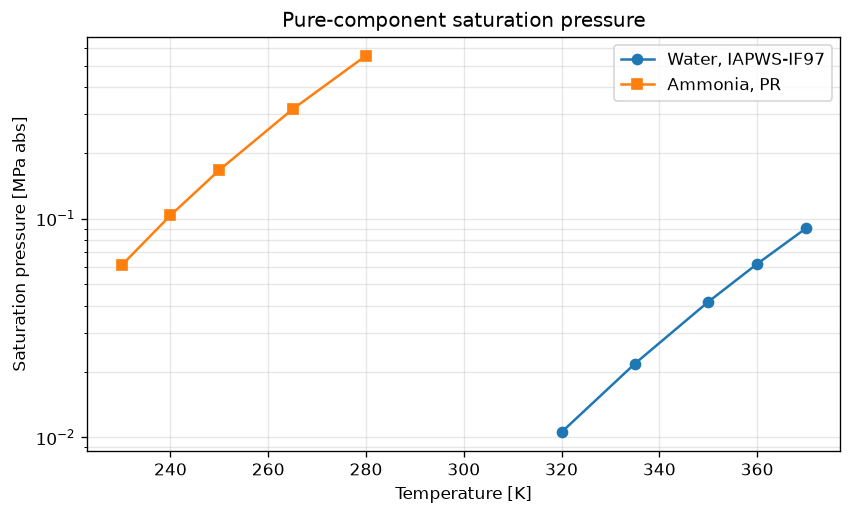

In [6]:
figure, axis = plt.subplots(figsize=(7.2, 4.4))
axis.semilogy(
    water_temperatures_kelvin,
    water_pressures_mpa,
    marker="o",
    label="Water, IAPWS-IF97",
)
axis.semilogy(
    ammonia_temperatures_kelvin,
    ammonia_pressures_mpa,
    marker="s",
    label="Ammonia, PR",
)
axis.set_xlabel("Temperature [K]")
axis.set_ylabel("Saturation pressure [MPa abs]")
axis.set_title("Pure-component saturation pressure")
axis.grid(True, which="both", alpha=0.3)
axis.legend()
figure.tight_layout()
plt.show()

## 3. Binary TP flash and phase interpretation

NeqSim stores the thermodynamic model, components, total composition, temperature, and pressure in a
fluid object. `TPflash` then minimises the appropriate thermodynamic potential and returns stable
equilibrium phases. For each component $i$, vapour–liquid equilibrium requires

$$

f_i^{L}=f_i^{V}

$$

where $f_i^{L}$ and $f_i^{V}$ are liquid- and vapour-phase fugacities in Pa. At 350 K and 1.0 MPa
absolute, the 20 mol% ammonia solution is expected to split into an ammonia-rich gas and a
water-rich aqueous phase in this screening model.

In [7]:
baseline_ammonia_fraction = 0.20
baseline_temperature_kelvin = 350.0
baseline_pressure_bara = 10.0

baseline_state = make_mixture(
    baseline_ammonia_fraction,
    baseline_temperature_kelvin,
    baseline_pressure_bara,
)
TPflash(baseline_state)
baseline_state.initProperties()

baseline_phase_table = phase_composition_table(baseline_state)
baseline_gas_fraction = gas_phase_fraction(baseline_state)

print(
    f"Equilibrium gas fraction: {baseline_gas_fraction:.6f} mol/mol"
)
print(baseline_phase_table.round(6).to_string(index=False))

Equilibrium gas fraction: 0.062170 mol/mol
  Phase  Phase fraction [mol/mol]  Ammonia [mol/mol]  Water [mol/mol]
    gas                   0.06217           0.962522         0.037478
aqueous                   0.93783           0.149452         0.850548


## 4. Independent component-balance check

For a two-phase flash, the feed composition must be reconstructed from the phase fractions and phase
compositions:

$$

z_i=(1-\beta)y_i^{L}+\beta y_i^{V}

$$

Here $z_i$ is the feed mole fraction, $\beta$ is the vapour mole fraction, and $y_i^{L}$ and
$y_i^{V}$ are phase mole fractions. The phase labels and ordering are discovered from NeqSim rather
than assumed, which makes the check robust to phase-index changes.

In [8]:
reconstructed_ammonia_fraction = 0.0
reconstructed_water_fraction = 0.0

for phase_index in range(baseline_state.getNumberOfPhases()):
    phase = baseline_state.getPhase(phase_index)
    phase_fraction = float(baseline_state.getBeta(phase_index))
    reconstructed_ammonia_fraction += phase_fraction * float(
        phase.getComponent("ammonia").getx()
    )
    reconstructed_water_fraction += phase_fraction * float(
        phase.getComponent("water").getx()
    )

ammonia_component_residual = (
    reconstructed_ammonia_fraction - baseline_ammonia_fraction
)
water_component_residual = (
    reconstructed_water_fraction - (1.0 - baseline_ammonia_fraction)
)

print(
    "Ammonia component residual: "
    f"{ammonia_component_residual:.3e} mol/mol"
)
print(
    "Water component residual: "
    f"{water_component_residual:.3e} mol/mol"
)

Ammonia component residual: 1.076e-12 mol/mol
Water component residual: -1.076e-12 mol/mol


## 5. Composition sensitivity at fixed pressure

The bubble temperature is the temperature at which the first infinitesimal vapour appears from a
liquid of specified composition. The governing condition can be written as

$$

\sum_i x_i K_i(T,P,\mathbf{x})=1

$$

where $x_i$ is liquid mole fraction and $K_i$ is the equilibrium ratio. At fixed pressure, adding
the more volatile ammonia should lower the bubble temperature. This is the central working-fluid
effect used in ammonia–water absorption and Kalina-cycle concepts.

In [9]:
composition_grid = np.array([0.02, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 0.95])
bubble_temperatures_kelvin = []

for ammonia_fraction in composition_grid:
    bubble_state = make_mixture(
        ammonia_fraction,
        330.0,
        baseline_pressure_bara,
    )
    bubt(bubble_state)
    bubble_temperatures_kelvin.append(
        float(bubble_state.getTemperature("K"))
    )

composition_table = pd.DataFrame(
    {
        "Ammonia [mol/mol]": composition_grid,
        "Bubble temperature [K]": bubble_temperatures_kelvin,
    }
)

print(composition_table.round(4).to_string(index=False))

 Ammonia [mol/mol]  Bubble temperature [K]
              0.02                429.4559
              0.05                398.9973
              0.10                367.1852
              0.20                339.2050
              0.40                319.4561
              0.60                310.6452
              0.80                304.2870
              0.95                299.5626


The monotonic trend is physically expected, but the exact curve is model-dependent. The strongest
temperature change occurs on the water-rich side in this calculation. Extrapolating a sparse
composition grid or using the curve outside 0.1–1.0 MPa without validation would be poor engineering
practice.

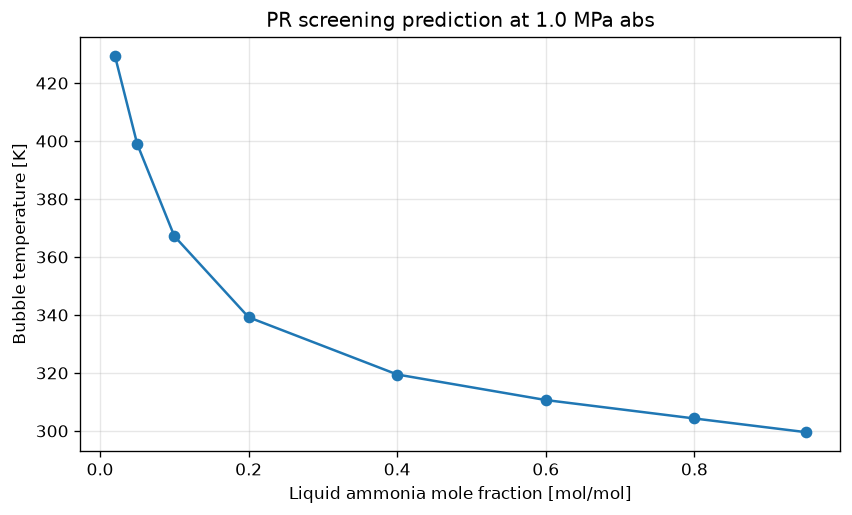

In [10]:
figure, axis = plt.subplots(figsize=(7.2, 4.4))
axis.plot(
    composition_grid,
    bubble_temperatures_kelvin,
    marker="o",
    color="tab:blue",
)
axis.set_xlabel("Liquid ammonia mole fraction [mol/mol]")
axis.set_ylabel("Bubble temperature [K]")
axis.set_title("PR screening prediction at 1.0 MPa abs")
axis.grid(True, alpha=0.3)
figure.tight_layout()
plt.show()

## 6. Pressure sensitivity of vapour generation

At fixed temperature and overall composition, increasing pressure suppresses vapour formation. The
gas fraction is reported on a molar basis. A value of zero means NeqSim found only a stable aqueous
phase at that state; it is not evidence that dissolved ammonia is absent.

In [11]:
pressure_grid_bara = np.array([5.0, 7.5, 10.0, 12.5, 15.0])
pressure_gas_fractions = []

for pressure_bara in pressure_grid_bara:
    pressure_state = make_mixture(
        baseline_ammonia_fraction,
        baseline_temperature_kelvin,
        pressure_bara,
    )
    TPflash(pressure_state)
    pressure_gas_fractions.append(gas_phase_fraction(pressure_state))

pressure_table = pd.DataFrame(
    {
        "Pressure [MPa abs]": pressure_grid_bara * 0.1,
        "Gas fraction [mol/mol]": pressure_gas_fractions,
    }
)

print(pressure_table.round(6).to_string(index=False))

 Pressure [MPa abs]  Gas fraction [mol/mol]
               0.50                0.158044
               0.75                0.113128
               1.00                0.062170
               1.25                0.000000
               1.50                0.000000


The limiting case is useful for debugging: sufficiently high pressure at fixed temperature should
produce a single liquid phase. A pressure increase that instead raised the vapour fraction would
signal a unit error, stale state, or failed phase-stability calculation.

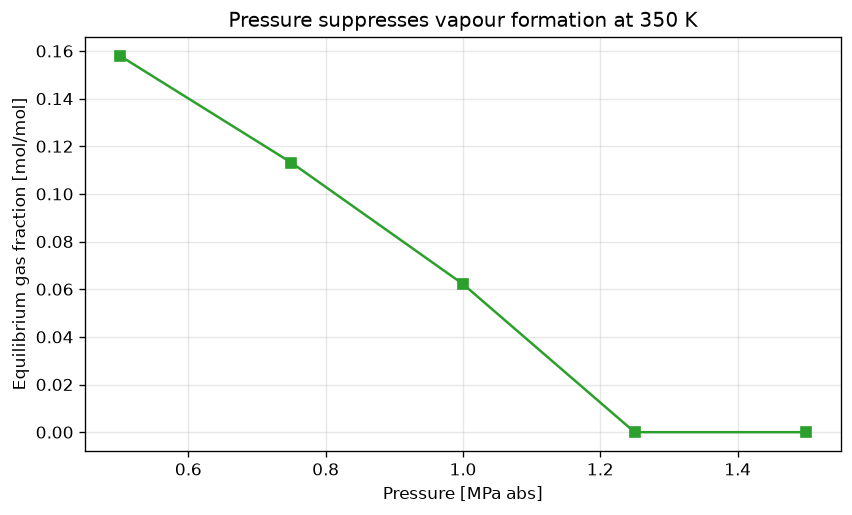

In [12]:
figure, axis = plt.subplots(figsize=(7.2, 4.4))
axis.plot(
    pressure_grid_bara * 0.1,
    pressure_gas_fractions,
    marker="s",
    color="tab:green",
)
axis.set_xlabel("Pressure [MPa abs]")
axis.set_ylabel("Equilibrium gas fraction [mol/mol]")
axis.set_title("Pressure suppresses vapour formation at 350 K")
axis.grid(True, alpha=0.3)
figure.tight_layout()
plt.show()

## 7. Model-form sensitivity

PR and SRK represent the cubic attractive term differently. Both calculations use the same
components, classical mixing rule, pressure, and composition, so their spread measures model form
rather than operating-condition changes. Association models may be better after regression, but an
unregressed CPA bubble flash for this binary system is deliberately excluded because it can converge
to initialization-sensitive aqueous branches instead of a reproducible vapour–liquid boundary.

In [13]:
model_rows = []

for model_name in ["PR", "SRK"]:
    model_state = make_mixture(
        baseline_ammonia_fraction,
        335.0,
        baseline_pressure_bara,
        model_name=model_name,
    )
    bubt(model_state)
    model_rows.append(
        {
            "Model": model_name,
            "Bubble temperature [K]": float(
                model_state.getTemperature("K")
            ),
        }
    )

model_table = pd.DataFrame(model_rows)
model_temperature_spread_kelvin = (
    model_table["Bubble temperature [K]"].max()
    - model_table["Bubble temperature [K]"].min()
)

print(model_table.round(4).to_string(index=False))
print(
    "Model spread: "
    f"{model_temperature_spread_kelvin:.3f} K"
)

Model  Bubble temperature [K]
   PR                339.2050
  SRK                334.9676
Model spread: 4.237 K


## 8. From a fluid to streams and a heater

NeqSim process calculations clone a thermodynamic fluid into a `stream`, connect it to unit
operations, and solve the graph with `runProcess()`. The heater specifies an outlet temperature;
NeqSim performs the outlet flash and obtains duty from the enthalpy change. For a steady heater with
no shaft work,

$$

\dot Q=\dot m(h_{\mathrm{out}}-h_{\mathrm{in}})

$$

where $\dot Q$ is duty in kW, $\dot m$ is mass flow in kg/s, and $h$ is specific enthalpy in kJ/kg.

In [14]:
clearProcess()
feed_state = make_mixture(
    baseline_ammonia_fraction,
    320.0,
    baseline_pressure_bara,
)
feed_stream = stream("Water-ammonia feed", feed_state)
feed_mass_flow_kg_per_second = 1.0
feed_stream.setFlowRate(
    feed_mass_flow_kg_per_second,
    "kg/sec",
)

solution_heater = heater("Solution heater", feed_stream)
solution_heater.setOutTemperature(
    baseline_temperature_kelvin,
    "K",
)
runProcess()

heated_stream = solution_heater.getOutletStream()
heated_state = heated_stream.getFluid()
heater_duty_kw = float(solution_heater.getDuty("kW"))

print(f"Heater duty: {heater_duty_kw:.6f} kW")
print(
    "Outlet gas fraction: "
    f"{gas_phase_fraction(heated_state):.6f} mol/mol"
)

Heater duty: 205.857766 kW
Outlet gas fraction: 0.062170 mol/mol


## 9. Independent energy balance and separator interpretation

The heater outlet contains two equilibrium phases, so it can be interpreted as the feed to an ideal
flash separator. Phase fractions are molar; equipment flow rates must be obtained using the
corresponding phase molar masses or phase flow methods. The independent duty calculation below uses
mass-specific enthalpy and therefore closes directly in kW.

In [15]:
feed_enthalpy_kj_per_kg = float(
    feed_stream.getFluid().getEnthalpy("kJ/kg")
)
outlet_enthalpy_kj_per_kg = float(
    heated_state.getEnthalpy("kJ/kg")
)
calculated_heater_duty_kw = feed_mass_flow_kg_per_second * (
    outlet_enthalpy_kj_per_kg - feed_enthalpy_kj_per_kg
)
heater_energy_residual_kw = (
    heater_duty_kw - calculated_heater_duty_kw
)

heated_phase_table = phase_composition_table(heated_state)

print(
    "Independent heater duty: "
    f"{calculated_heater_duty_kw:.6f} kW"
)
print(
    "Energy-balance residual: "
    f"{heater_energy_residual_kw:.3e} kW"
)
print(heated_phase_table.round(6).to_string(index=False))

Independent heater duty: 205.857766 kW
Energy-balance residual: 1.705e-13 kW
  Phase  Phase fraction [mol/mol]  Ammonia [mol/mol]  Water [mol/mol]
    gas                   0.06217           0.962522         0.037478
aqueous                   0.93783           0.149452         0.850548


## 10. Outlet-temperature scenario analysis

Heating both raises enthalpy and changes phase split. The scenario table reruns the complete process
for each outlet temperature rather than mutating a previously solved state. This avoids hidden state
and makes the duty and vapour-fraction trends reproducible.

In [16]:
def run_heater_case(outlet_temperature_kelvin):
    clearProcess()
    case_state = make_mixture(
        baseline_ammonia_fraction,
        320.0,
        baseline_pressure_bara,
    )
    case_feed = stream("Case feed", case_state)
    case_feed.setFlowRate(
        feed_mass_flow_kg_per_second,
        "kg/sec",
    )
    case_heater = heater("Case heater", case_feed)
    case_heater.setOutTemperature(
        outlet_temperature_kelvin,
        "K",
    )
    runProcess()
    case_outlet = case_heater.getOutletStream().getFluid()
    return {
        "Outlet temperature [K]": outlet_temperature_kelvin,
        "Duty [kW]": float(case_heater.getDuty("kW")),
        "Gas fraction [mol/mol]": gas_phase_fraction(case_outlet),
    }


outlet_temperature_grid_kelvin = np.array([325.0, 335.0, 345.0, 355.0, 365.0])
heater_sensitivity_table = pd.DataFrame(
    [
        run_heater_case(outlet_temperature_kelvin)
        for outlet_temperature_kelvin in outlet_temperature_grid_kelvin
    ]
)

print(heater_sensitivity_table.round(6).to_string(index=False))

 Outlet temperature [K]  Duty [kW]  Gas fraction [mol/mol]
                  325.0  23.206351                0.000000
                  335.0  69.808385                0.000000
                  345.0 156.141765                0.037284
                  355.0 251.009725                0.082604
                  365.0 333.740332                0.115281


The duty should increase monotonically. Vapour generation begins only after the case crosses its
bubble boundary, so the gas-fraction curve can contain an initial zero plateau. That phase change
also increases the duty slope because latent heat is required.

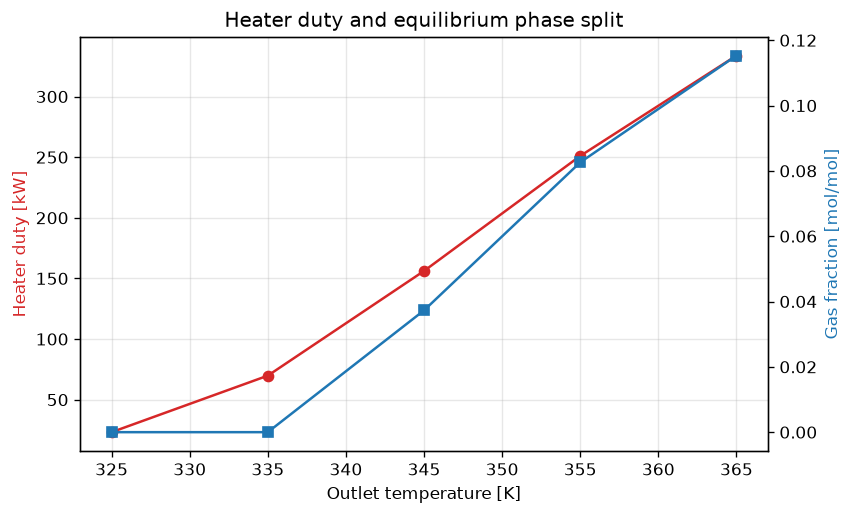

In [17]:
figure, primary_axis = plt.subplots(figsize=(7.2, 4.4))
secondary_axis = primary_axis.twinx()

primary_axis.plot(
    heater_sensitivity_table["Outlet temperature [K]"],
    heater_sensitivity_table["Duty [kW]"],
    marker="o",
    color="tab:red",
    label="Heater duty",
)
secondary_axis.plot(
    heater_sensitivity_table["Outlet temperature [K]"],
    heater_sensitivity_table["Gas fraction [mol/mol]"],
    marker="s",
    color="tab:blue",
    label="Gas fraction",
)

primary_axis.set_xlabel("Outlet temperature [K]")
primary_axis.set_ylabel("Heater duty [kW]", color="tab:red")
secondary_axis.set_ylabel("Gas fraction [mol/mol]", color="tab:blue")
primary_axis.set_title("Heater duty and equilibrium phase split")
primary_axis.grid(True, alpha=0.3)
figure.tight_layout()
plt.show()

## 11. Verification, troubleshooting, and practical limits

The final cell checks benchmarks, conservation, phase behaviour, finite values, and expected
sensitivity trends. If a flash fails, first confirm that temperature is in K and pressure is
absolute, recreate the fluid rather than reusing a failed state, enable multiphase checking, and use
a reasonable initial temperature near the expected bubble point. If a phase disappears, treat that
as a possible stable single-phase result before assuming solver failure.

Key limitations remain: the binary mixing rule is not regressed, chemical speciation is excluded,
and transport properties, corrosion, kinetics, and equipment mass transfer are outside the model.
Never use this screening notebook alone for absorber sizing, toxicity assessment, or relief design.

In [18]:
numeric_tables = [
    pure_boiling_table,
    saturation_table,
    baseline_phase_table,
    composition_table,
    pressure_table,
    model_table,
    heated_phase_table,
    heater_sensitivity_table,
]

verification_checks = {
    "NeqSim version recorded": bool(neqsim_version),
    "water normal boiling benchmark": abs(
        pure_boiling_table.loc[0, "Difference [K]"]
    ) < 0.3,
    "ammonia normal boiling benchmark": abs(
        pure_boiling_table.loc[1, "Difference [K]"]
    ) < 0.5,
    "water saturation pressure increasing": bool(
        np.all(np.diff(water_pressures_mpa) > 0.0)
    ),
    "ammonia saturation pressure increasing": bool(
        np.all(np.diff(ammonia_pressures_mpa) > 0.0)
    ),
    "baseline has two phases": baseline_state.getNumberOfPhases() == 2,
    "gas richer in ammonia": bool(
        baseline_phase_table.loc[
            baseline_phase_table["Phase"] == "gas",
            "Ammonia [mol/mol]",
        ].iloc[0]
        > baseline_ammonia_fraction
    ),
    "ammonia component closure": abs(ammonia_component_residual) < 1.0e-10,
    "water component closure": abs(water_component_residual) < 1.0e-10,
    "bubble temperature decreases with ammonia": bool(
        np.all(np.diff(bubble_temperatures_kelvin) < 0.0)
    ),
    "gas fraction decreases with pressure": bool(
        np.all(np.diff(pressure_gas_fractions) <= 0.0)
    ),
    "high-pressure liquid limit": pressure_gas_fractions[-1] == 0.0,
    "model comparison finite": bool(
        np.isfinite(model_table["Bubble temperature [K]"]).all()
    ),
    "model sensitivity visible": model_temperature_spread_kelvin > 1.0,
    "heater duty positive": heater_duty_kw > 0.0,
    "heater energy closure": abs(heater_energy_residual_kw) < 1.0e-8,
    "heater duty increasing": bool(
        np.all(np.diff(heater_sensitivity_table["Duty [kW]"]) > 0.0)
    ),
    "heater vapour response increasing": bool(
        np.all(
            np.diff(
                heater_sensitivity_table["Gas fraction [mol/mol]"]
            )
            >= 0.0
        )
    ),
    "all displayed numbers finite": all(
        np.isfinite(table.select_dtypes(include=[float, int])).all().all()
        for table in numeric_tables
    ),
}

failed_checks = [
    name
    for name, passed in verification_checks.items()
    if not passed
]

assert not failed_checks, f"Failed checks: {failed_checks}"
print(f"All {len(verification_checks)} engineering checks passed.")

All 19 engineering checks passed.


## Summary, exercises, and references

NeqSim represents the fluid and thermodynamic model in one state object, flash operations determine
equilibrium phases, and process streams pass cloned states between unit operations. The calculations
verified pure-component anchors, component and energy closure, composition and pressure limits, and
model-form sensitivity. The result is suitable for learning and screening, with explicit warnings
against unvalidated design use.

**Further exercises**

1. Repeat the pressure study at 340 K and explain the shifted single-phase boundary.
2. Replace the classical mixing rule with a regressed rule only after locating suitable VLE data.
3. Convert molar phase fractions to mass flow rates and verify total mass closure.
4. Add a cooler after the flash and track how much ammonia is reabsorbed.

**Authoritative references**

- [NeqSim thermodynamic model selection](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [NeqSim thermodynamic operations](https://equinor.github.io/neqsim/thermodynamicoperations/README.html)
- [NeqSim process recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html)
- [IAPWS Industrial Formulation 1997](https://iapws.org/relguide/IF97-Rev.html)
- [NIST Chemistry WebBook: water](https://webbook.nist.gov/cgi/cbook.cgi?ID=C7732185&Mask=4)
- [NIST Chemistry WebBook: ammonia](https://webbook.nist.gov/cgi/cbook.cgi?ID=C7664417&Mask=4)